<a href="https://www.kaggle.com/code/ntirth005/embryo-dataset?scriptVersionId=310104960" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## Imports and Global Config

In [1]:
!pip install -q timm

import os, re, glob, random
import numpy as np
import pandas as pd
from PIL import Image, ImageFile
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter
from tqdm import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
SETTINGS = dict(
    data_root      = '/kaggle/input/datasets/naumisharanyatirth/human-embryo-dataset',
    save_dir       = '/kaggle/working/results',
    image_size     = 224,
    batch_size     = 512,      # keep <= 512 or OOM occur
    epochs         = 4,        # fine for testing, use 12 for final
    lr             = 3e-4,
    weight_decay   = 1e-4,
    num_workers    = 4,
    seed           = 42,
    device         = 'cuda' if torch.cuda.is_available() else 'cpu',
    sigma          = 1.5,
    ordinal_beta   = 0.4,
)
torch.manual_seed(SETTINGS['seed'])
np.random.seed(SETTINGS['seed'])
DEVICE = SETTINGS['device']
os.makedirs(SETTINGS['save_dir'], exist_ok=True)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
print(f'Device  : {DEVICE}')
print(f'Torch   : {torch.__version__}')
print('Settings:', SETTINGS)

Device  : cuda
Torch   : 2.10.0+cu128
Settings: {'data_root': '/kaggle/input/datasets/naumisharanyatirth/human-embryo-dataset', 'save_dir': '/kaggle/working/results', 'image_size': 224, 'batch_size': 512, 'epochs': 4, 'lr': 0.0003, 'weight_decay': 0.0001, 'num_workers': 4, 'seed': 42, 'device': 'cuda', 'sigma': 1.5, 'ordinal_beta': 0.4}


## Stage Labels

In [3]:
STAGES = [
    "tPB2","tPNa","tPNf","t2","t3","t4","t5","t6",
    "t7","t8","t9+","tM","tSB","tB","tEB","tHB"
]
LABEL_MAP     = {stage: idx for idx, stage in enumerate(STAGES)}
TOTAL_CLASSES = len(STAGES)
num_classes = len(STAGES)
print(f'{TOTAL_CLASSES} stages defined:', STAGES)

16 stages defined: ['tPB2', 'tPNa', 'tPNf', 't2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+', 'tM', 'tSB', 'tB', 'tEB', 'tHB']


## Download and Extract Dataset

In [4]:
# SOURCE_URLS = {
#     'images'      : 'https://zenodo.org/records/6390798/files/embryo_dataset.tar.gz',
#     'annotations' : 'https://zenodo.org/records/6390798/files/embryo_dataset_annotations.tar.gz',
# }

# def fetch_and_unpack(url: str, destination: str):
#     os.makedirs(destination, exist_ok=True)
#     filename = os.path.join(destination, url.split('/')[-1])

#     if not os.path.exists(filename):
#         print(f'Downloading {url.split("/")[-1]} ...')
#         urllib.request.urlretrieve(url, filename)
#         print('  Download complete.')
#     else:
#         print(f'  {filename} already present, skipping.')

#     print('  Unpacking ...')
#     with tarfile.open(filename, 'r:gz') as archive:
#         archive.extractall(destination)
#     print('  Done.')

# for key, url in SOURCE_URLS.items():
#     fetch_and_unpack(url, SETTINGS['data_root'])

# print('\nDataset folder preview:')
# for p in sorted(Path(SETTINGS['data_root']).rglob('*'))[:30]:
#     print(' ', p)

## Dataset and DataLoaders

Total samples collected: 297428
Train=236023 | Val=30703 | Test=30702


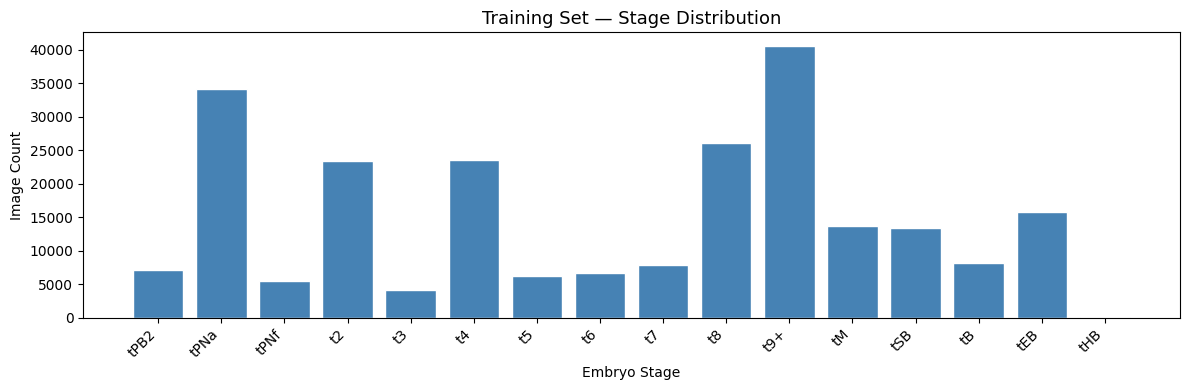

In [5]:
ImageFile.LOAD_TRUNCATED_IMAGES = True 

class StageImageDataset(Dataset):
    def __init__(self, file_label_pairs, transform=None):
        self.pairs     = tuple(file_label_pairs)  
        self.transform = transform

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        path, label = self.pairs[idx]
        try:
            with Image.open(path) as img:
                img = img.convert('RGB')
                img.load()              
        except Exception:
            img = Image.new('RGB', (224, 224), 0)
        if self.transform:
            img = self.transform(img)
        return img, label

def collect_samples(data_root: str):
    data_root  = Path(data_root)
    img_root   = data_root / 'embryo_dataset'
    ann_root   = data_root / 'embryo_dataset_annotations'
    records    = []
    for csv_path in sorted(ann_root.glob('*_phases.csv')):
        patient_id  = csv_path.stem.replace('_phases', '')   # e.g. AA83-7
        patient_dir = img_root / patient_id
        if not patient_dir.exists(): continue

        # Build frame_number → image_path lookup for this patient
        frame_map = {}
        for img_file in patient_dir.iterdir():
            # filename like D2013.01.28_S0717_I132_WELL7_RUN1.jpeg
            # frame number is the RUN number at the end
            stem = img_file.stem                          
            run_part = stem.split('RUN')[-1]        
            if run_part.isdigit():
                frame_map[int(run_part)] = img_file

        df = pd.read_csv(csv_path, header=None,
                         names=['stage', 'start', 'end'])
        for _, row in df.iterrows():
            stage = str(row['stage']).strip()
            if stage not in LABEL_MAP: continue
            for frame in range(int(row['start']), int(row['end']) + 1):
                if frame in frame_map:
                    records.append((str(frame_map[frame]), LABEL_MAP[stage]))

    if not records:
        raise FileNotFoundError('No samples found — check dataset paths.')
    
    print(f'Total samples collected: {len(records)}')
    return records

#  LOAD DATA (same)
all_samples = collect_samples(SETTINGS['data_root'])

# Extract patient_id from path
def get_patient_id(path):
    return Path(path).parent.name


#  GROUP BY PATIENT
patient_dict = {}

for path, label in all_samples:
    pid = get_patient_id(path)
    if pid not in patient_dict:
        patient_dict[pid] = []
    patient_dict[pid].append((path, label))

patient_ids = list(patient_dict.keys())


# PATIENT-WISE SPLIT
train_pids, temp_pids = train_test_split(
    patient_ids,
    test_size=0.2,
    random_state=SETTINGS['seed']
)

val_pids, test_pids = train_test_split(
    temp_pids,
    test_size=0.5,
    random_state=SETTINGS['seed']
)


# FLATTEN BACK TO FRAME LIST
def collect_from_pids(pids):
    data = []
    for pid in pids:
        data.extend(patient_dict[pid])
    return data


train_set = collect_from_pids(train_pids)
val_set   = collect_from_pids(val_pids)
test_set  = collect_from_pids(test_pids)

train_labels = np.array([y for _, y in train_set])
def get_transforms(dim):
    train_tf = transforms.Compose([
        transforms.Resize((dim, dim)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(0.2, 0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])

    eval_tf = transforms.Compose([
        transforms.Resize((dim, dim)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])

    return train_tf, eval_tf


train_tf_224, eval_tf_224 = get_transforms(224)
train_tf_299, eval_tf_299 = get_transforms(299)


def make_loader(dataset, transform, batch_size, shuffle):
    return DataLoader(
        StageImageDataset(dataset, transform),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=4, 
        pin_memory=True,
        persistent_workers=False,
        prefetch_factor=2
    )

train_loader = make_loader(train_set, train_tf_224, SETTINGS['batch_size'], True)
val_loader   = make_loader(val_set,   eval_tf_224, SETTINGS['batch_size'], False)

inc_train = make_loader(train_set, train_tf_299, SETTINGS['batch_size'], True)
inc_val   = make_loader(val_set,   eval_tf_299, SETTINGS['batch_size'], False)


print(f"Train={len(train_set)} | Val={len(val_set)} | Test={len(test_set)}")

# Class distribution plot
stage_counts = np.bincount(train_labels, minlength=TOTAL_CLASSES)
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(STAGES, stage_counts, color='steelblue', edgecolor='white')
ax.set_title('Training Set — Stage Distribution', fontsize=13)
ax.set_xlabel('Embryo Stage'); ax.set_ylabel('Image Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

In [6]:
class SoftOrdinalMarginLoss(nn.Module):
    """
    L = -sum_c [ alpha_c * y_soft_c * log(p_c) ]   [Ordinal-smoothed CE]
      + beta  * sum_c [ p_c * log(1 + |c - y|) ]    [Log-margin ordinal penalty]

    Desirable Properties:
    ┌─────────────────────┬──────────────────────────────────────────────┐
    │ Property            │ Mechanism                                    │
    ├─────────────────────┼──────────────────────────────────────────────┤
    │ Non-negativity      │ Both terms >= 0 by construction              │
    │ Zero at optimum     │ -> 0 as p_true -> 1 and mass on true class   │
    │ Differentiability   │ softmax + log + log1p — all C-infinity       │
    │ Class imbalance     │ alpha = 1/freq, mean-normalised              │
    │ Ordinal awareness   │ log-margin penalises distant stage errors    │
    └─────────────────────┴──────────────────────────────────────────────┘

    Args:
        class_weights : (C,) inverse-frequency weights per class
        sigma         : Gaussian spread for soft ordinal labels
        ordinal_beta  : weight of the log-margin ordinal penalty
        num_classes   : number of stage classes
    """
    def __init__(self,
                 class_weights : torch.Tensor,
                 sigma         : float = 1.5,
                 ordinal_beta  : float = 0.4,
                 num_classes   : int   = 16):
        super().__init__()
        self.register_buffer('class_weights', class_weights)
        self.sigma        = sigma
        self.ordinal_beta = ordinal_beta
        self.num_classes  = num_classes
        self.register_buffer('stage_indices',
            torch.arange(num_classes, dtype=torch.float32))

        # Precompute Gaussian soft label bank — shape (C, C)
        # Row i = soft target distribution when true class is i
        soft = torch.zeros(num_classes, num_classes)
        for i in range(num_classes):
            dists   = (torch.arange(num_classes) - i).float()
            soft[i] = torch.exp(-dists**2 / (2 * sigma**2))
            soft[i] /= soft[i].sum()          # normalise to sum=1
        self.register_buffer('soft_label_bank', soft)

    def forward(self, logits: torch.Tensor,
                targets: torch.Tensor) -> torch.Tensor:
        B, C    = logits.shape
        log_p   = F.log_softmax(logits, dim=1)         # (B, C)
        probs   = log_p.exp()                          # (B, C)
        soft_y  = self.soft_label_bank[targets]        # (B, C)
        alpha_t = self.class_weights[targets]          # (B,)

        # (a) Ordinal-smoothed CE
        smooth_ce = -(alpha_t.unsqueeze(1) *
                      soft_y * log_p).sum(dim=1)       # (B,)

        # (b) Log-margin ordinal penalty
        stage_dist = torch.abs(
            self.stage_indices.unsqueeze(0) -
            targets.float().unsqueeze(1))              # (B, C)
        ordinal = (probs * torch.log1p(stage_dist)
                   ).sum(dim=1)                        # (B,)

        return (smooth_ce + self.ordinal_beta * ordinal).mean()

    @staticmethod
    def compute_class_weights(train_labels: np.ndarray,
                               num_classes: int) -> torch.Tensor:
        counts  = np.bincount(train_labels, minlength=num_classes).astype(float)
        counts  = np.where(counts == 0, 1, counts)
        weights = 1.0 / counts
        weights = weights / weights.mean()             # mean-normalise
        return torch.tensor(weights, dtype=torch.float32)


# Instantiate
class_weights = SoftOrdinalMarginLoss.compute_class_weights(
    train_labels, TOTAL_CLASSES).to(DEVICE)

criterion = SoftOrdinalMarginLoss(
    class_weights = class_weights,
    sigma         = SETTINGS['sigma'],
    ordinal_beta  = SETTINGS['ordinal_beta'],
    num_classes   = TOTAL_CLASSES,
).to(DEVICE)
print('SoftOrdinalMarginLoss ready ✔')
print('Class weights:',
      dict(zip(STAGES, class_weights.cpu().numpy().round(3))))


# Unit Tests
def make_confident_logits(B, C, cls, conf=0.999):
    lg = torch.full((B, C), -2.0)
    lg[:, cls] = float(np.log(conf / (1 - conf + 1e-9)))
    return lg

cw_test = torch.ones(TOTAL_CLASSES).to(DEVICE)
L_test  = SoftOrdinalMarginLoss(cw_test, sigma=1.5, ordinal_beta=0.4,
                                 num_classes=TOTAL_CLASSES).to(DEVICE)

# 1. Non-negativity
neg_ok = all(
    L_test(torch.randn(16, TOTAL_CLASSES).to(DEVICE),
           torch.randint(0, TOTAL_CLASSES, (16,)).to(DEVICE)).item() >= -1e-6
    for _ in range(200)
)
print(f'1. Non-negativity    : {"PASS ✔" if neg_ok else "FAIL ✘"}')

# 2. Zero at optimum
opt_losses = [
    L_test(make_confident_logits(32, TOTAL_CLASSES, c).to(DEVICE),
           torch.full((32,), c, dtype=torch.long).to(DEVICE)).item()
    for c in range(TOTAL_CLASSES)
]
print(f'2. Zero at optimum   : max_loss={max(opt_losses):.6f}  (→ 0 ✔)')

# 3. Differentiability
lg = torch.randn(8, TOTAL_CLASSES).to(DEVICE)
lg = lg.detach().requires_grad_(True)       
tg = torch.randint(0, TOTAL_CLASSES, (8,)).to(DEVICE)
loss = L_test(lg, tg)
loss.backward()
grad_ok = lg.grad is not None and not torch.isnan(lg.grad).any()
print(f'3. Differentiability : {"PASS ✔" if grad_ok else "FAIL ✘"}')

# 4. Class imbalance awareness
skewed        = torch.ones(TOTAL_CLASSES).to(DEVICE)
skewed[0]     = 10.0
L_skew        = SoftOrdinalMarginLoss(skewed, ordinal_beta=0.0).to(DEVICE)
l_rare        = L_skew(make_confident_logits(8, TOTAL_CLASSES, 1).to(DEVICE),
                       torch.zeros(8, dtype=torch.long).to(DEVICE)).item()
l_major       = L_skew(make_confident_logits(8, TOTAL_CLASSES, 0).to(DEVICE),
                       torch.ones(8, dtype=torch.long).to(DEVICE)).item()
print(f'4. Class imbalance   : rare={l_rare:.4f} major={l_major:.4f} '
      f'{"(rare > major ✔)" if l_rare > l_major else "WARN"}')

# 5. Ordinal penalty
t_cls  = 5
tgts   = torch.full((8,), t_cls, dtype=torch.long).to(DEVICE)
l_near = L_test(make_confident_logits(8, TOTAL_CLASSES, t_cls+1).to(DEVICE), tgts).item()
l_far  = L_test(make_confident_logits(8, TOTAL_CLASSES, t_cls+5).to(DEVICE), tgts).item()
print(f'5. Ordinal penalty   : near={l_near:.4f} far={l_far:.4f} '
      f'{"(far > near ✔)" if l_far > l_near else "WARN"}')

SoftOrdinalMarginLoss ready ✔
Class weights: {'tPB2': np.float32(0.071), 'tPNa': np.float32(0.015), 'tPNf': np.float32(0.092), 't2': np.float32(0.021), 't3': np.float32(0.123), 't4': np.float32(0.021), 't5': np.float32(0.081), 't6': np.float32(0.076), 't7': np.float32(0.064), 't8': np.float32(0.019), 't9+': np.float32(0.012), 'tM': np.float32(0.037), 'tSB': np.float32(0.037), 'tB': np.float32(0.062), 'tEB': np.float32(0.032), 'tHB': np.float32(15.235)}
1. Non-negativity    : PASS ✔
2. Zero at optimum   : max_loss=6.541196  (→ 0 ✔)
3. Differentiability : PASS ✔
4. Class imbalance   : rare=59.1212 major=6.6665 (rare > major ✔)
5. Ordinal penalty   : near=7.2897 far=9.6161 (far > near ✔)


In [7]:
def get_model(name):
    if name == "mobilenet":
        model = models.mobilenet_v2(weights="IMAGENET1K_V1")
        model.classifier[1] = nn.Linear(model.last_channel, num_classes)

    elif name == "inception":
        model = models.inception_v3(weights="IMAGENET1K_V1")
        model.aux_logits = False
        model.AuxLogits = None
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif name == "vgg16":
        model = models.vgg16(weights="IMAGENET1K_V1")
        model.classifier[6] = nn.Linear(4096, num_classes)

    elif name == "vgg19":
        model = models.vgg19(weights="IMAGENET1K_V1")
        model.classifier[6] = nn.Linear(4096, num_classes)

    return model

In [8]:
def prepare_model(model):
    model = model.to(DEVICE)

    if torch.cuda.device_count() > 1:
        print("Using", torch.cuda.device_count(), "GPUs")
        model = nn.DataParallel(model)

    return model

In [9]:
import os

def train_model(model, train_loader, val_loader, train_labels,
                num_classes=16, epochs=5, name="model"):

    model = model.to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    class_weights = SoftOrdinalMarginLoss.compute_class_weights(
        train_labels, num_classes
    ).to(DEVICE)

    criterion = SoftOrdinalMarginLoss(
        class_weights = class_weights,
        sigma         = SETTINGS['sigma'],
        ordinal_beta  = SETTINGS['ordinal_beta'],
        num_classes   = num_classes,
    ).to(DEVICE)

    scaler = torch.amp.GradScaler('cuda')

    # Checkpoint Paths
    ckpt_path = f"{name}_checkpoint_v2.pth"
    best_path = f"{name}_best_v2.pth"

    start_epoch = 0
    best_loss = float("inf")

    # Resume if Checkpoint exists
    if os.path.exists(ckpt_path):
        print(f"Loading checkpoint: {ckpt_path}")
        checkpoint = torch.load(ckpt_path, map_location=DEVICE)

        model.load_state_dict(checkpoint["model"])
        optimizer.load_state_dict(checkpoint["optimizer"])
        scaler.load_state_dict(checkpoint["scaler"])

        start_epoch = checkpoint["epoch"] + 1
        best_loss   = checkpoint["best_loss"]

        print(f"Resumed from epoch {start_epoch}")


    # Train Loop
    for epoch in range(start_epoch, epochs):
        model.train()
        total_loss = 0

        loop = tqdm(enumerate(train_loader), total=len(train_loader))

        for step, (imgs, labels) in loop:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                outputs = model(imgs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

        
        # Validation
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        print(f"Epoch {epoch}: Train {total_loss:.3f} | Val Loss {val_loss:.3f} | Val Acc {val_acc:.4f}")


        # Save Best Model
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), best_path)
            print("Best model saved")


        # Save Checkpoint(per epoch)
        torch.save({
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scaler": scaler.state_dict(),
            "best_loss": best_loss
        }, ckpt_path)

        print("Checkpoint saved")

    print(f"Training complete for {name}")

In [10]:
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(imgs)

            # Inception safety
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy


def evaluate_best_model(model_name, loader, train_labels, num_classes=16):

    print(f"\nEvaluating {model_name.upper()}")

    model = prepare_model(get_model(model_name))

    best_path = f"{model_name}_best_v2.pth"
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))

    model.eval()

    # Recreate loss
    class_weights = SoftOrdinalMarginLoss.compute_class_weights(
        train_labels, num_classes
    ).to(DEVICE)

    criterion = SoftOrdinalMarginLoss(
        class_weights = class_weights,
        sigma         = SETTINGS['sigma'],
        ordinal_beta  = SETTINGS['ordinal_beta'],
        num_classes   = num_classes,
    ).to(DEVICE)

    loss, acc = evaluate(model, loader, criterion)

    print(f"{model_name} → Loss: {loss:.4f} | Accuracy: {acc:.4f}")

    return loss, acc

In [20]:
# torch.cuda.empty_cache()
# import gc; gc.collect()

0

## Train MobileNet

In [15]:
# MobileNet
model = prepare_model(get_model("mobilenet"))
train_model(model, train_loader, val_loader, train_labels, epochs=4, name="mobilenet")

Using 2 GPUs
Loading checkpoint: mobilenet_checkpoint_v2.pth
Resumed from epoch 3


100%|██████████| 461/461 [35:00<00:00,  4.56s/it]


Epoch 3: Train 103.409 | Val Loss 0.234 | Val Acc 0.6815
Best model saved
Checkpoint saved
Training complete for mobilenet


## Train Inception

In [14]:
# Inception
model = prepare_model(get_model("inception"))
train_model(model, train_loader, val_loader, train_labels, epochs=4, name="inception")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 199MB/s]  


Using 2 GPUs


100%|██████████| 461/461 [13:48<00:00,  1.80s/it]


Epoch 0: Train 115.452 | Val Loss 0.241 | Val Acc 0.6590
Best model saved
Checkpoint saved


...

Epoch 1: Train 90.881 | Val Loss 0.233 | Val Acc 0.6718
Best model saved
Checkpoint saved


100%|██████████| 461/461 [13:57<00:00,  1.82s/it]


Epoch 2: Train 82.924 | Val Loss 0.230 | Val Acc 0.6721
Best model saved
Checkpoint saved


100%|██████████| 461/461 [14:31<00:00,  1.89s/it]


Epoch 3: Train 78.370 | Val Loss 0.236 | Val Acc 0.6644
Checkpoint saved
Training complete for inception


## Train VGG16

In [12]:
# VGG16
model = prepare_model(get_model("vgg16"))
train_model(model, train_loader, val_loader, train_labels, epochs=4, name="vgg16")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 217MB/s]  


Using 2 GPUs


100%|██████████| 461/461 [18:21<00:00,  2.39s/it]


Epoch 0: Train 121.544 | Val Loss 0.233 | Val Acc 0.6769
Best model saved
Checkpoint saved


...

Epoch 1: Train 97.462 | Val Loss 0.234 | Val Acc 0.6701
Checkpoint saved


100%|██████████| 461/461 [15:12<00:00,  1.98s/it]


Epoch 2: Train 88.269 | Val Loss 0.234 | Val Acc 0.6661
Checkpoint saved


100%|██████████| 461/461 [14:46<00:00,  1.92s/it]


Epoch 3: Train 82.072 | Val Loss 0.237 | Val Acc 0.6640
Checkpoint saved
Training complete for vgg16


## Train VGG19


In [12]:
# VGG19
model = prepare_model(get_model("vgg19"))
train_model(model, train_loader, val_loader, train_labels, epochs=4, name="vgg19")

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 203MB/s]  


Using 2 GPUs


100%|██████████| 461/461 [17:53<00:00,  2.33s/it]


Epoch 0: Train 120.866 | Val Loss 0.248 | Val Acc 0.6483
Best model saved
Checkpoint saved


...

Epoch 1: Train 98.519 | Val Loss 0.235 | Val Acc 0.6824
Best model saved
Checkpoint saved


100%|██████████| 461/461 [17:22<00:00,  2.26s/it]


Epoch 2: Train 90.451 | Val Loss 0.223 | Val Acc 0.6986
Best model saved
Checkpoint saved


100%|██████████| 461/461 [17:24<00:00,  2.27s/it]


Epoch 3: Train 84.924 | Val Loss 0.228 | Val Acc 0.6872
Checkpoint saved
Training complete for vgg19


## Test Loader

In [15]:
test_loader = make_loader(test_set, eval_tf_224, SETTINGS['batch_size'], False)
inc_test    = make_loader(test_set, eval_tf_299, SETTINGS['batch_size'], False)

print(f"Test loaders ready: {len(test_set)} samples")

Test loaders ready: 30702 samples


## Test Evaluation

In [20]:
print("\nTEST SET EVALUATION")

test_results = {}

test_results["vgg16"] = evaluate_best_model(
    "vgg16", test_loader, train_labels
)

# test_results["vgg19"] = evaluate_best_model(
#     "vgg19", test_loader, train_labels
# )

test_results["inception"] = evaluate_best_model(
    "inception", inc_test, train_labels
)

print("\nTEST RESULTS:")
for k, v in test_results.items():
    print(f"{k}: Loss={v[0]:.4f}, Acc={v[1]:.4f}")


TEST SET EVALUATION

Evaluating VGG16
Using 2 GPUs
vgg16 → Loss: 0.3385 | Accuracy: 0.6087

Evaluating INCEPTION
Using 2 GPUs
inception → Loss: 0.4711 | Accuracy: 0.4310

TEST RESULTS:
vgg16: Loss=0.3385, Acc=0.6087
inception: Loss=0.4711, Acc=0.4310


In [17]:
import torch

# Path to your checkpoint
ckpt_path = "/kaggle/input/models/naumisharanyatirth/mobilenet/pytorch/default/4/mobilenet_best_v2.pth"

# Load checkpoint
checkpoint = torch.load(ckpt_path, map_location="cpu")

torch.save(checkpoint, "mobilenet_best_v2.pth")

In [21]:
test_results = {}

test_results["vgg19"] = evaluate_best_model(
    "vgg19", test_loader, train_labels
)

test_results["mobilenet"] = evaluate_best_model(
    "mobilenet", test_loader, train_labels
)

print("\nTEST RESULTS:")
for k, v in test_results.items():
    print(f"{k}: Loss={v[0]:.4f}, Acc={v[1]:.4f}")


Evaluating VGG19
Using 2 GPUs
vgg19 → Loss: 0.3303 | Accuracy: 0.6230

Evaluating MOBILENET
Using 2 GPUs
mobilenet → Loss: 0.3551 | Accuracy: 0.6066

TEST RESULTS:
vgg19: Loss=0.3303, Acc=0.6230
mobilenet: Loss=0.3551, Acc=0.6066
